# Projet : Analyse des ventes de la librairie Lapage
**Auteur :** Rémy D'AURA | **Date :** [17/03/2026] | **Objectif :** Analyser les points forts, les points faibles et les comportements clients pour le CODIR.

##  Contexte
La librairie en ligne Lapage souhaite faire le point sur ses ventes. Annabelle (Marketing) a besoin d'indicateurs clés de performance (Chiffre d'Affaires, Tops/Flops, Profils clients). Julie (Data) souhaite que l'on valide statistiquement certaines hypothèses sur le comportement des clients. 

**Plan de l'analyse :**
1. Préparation et Nettoyage des données
2. Analyse Globale des Ventes (Indicateurs clés)
3. Analyse de la concentration (B2B vs B2C)
4. Tests Statistiques des comportements clients (Analyses bivariées)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pingouin as pg

# Chargement des fichiers
customers = pd.read_csv('customers.csv', sep=';')
products = pd.read_csv('products.csv', sep=';')
# Chargement avec l'option low_memory pour éviter le DtypeWarning
transactions = pd.read_csv('Transactions.csv', sep=';', low_memory=False)

##  Partie 1 : Préparation et Nettoyage des Données
Avant de calculer nos indicateurs, nous devons nous assurer que notre base de données est saine. Nous allons importer les 3 fichiers fournis (`customers`, `products`, `transactions`), vérifier l'absence de valeurs manquantes ou de données de test, puis les fusionner en une seule base centralisée (Master Table).

In [2]:
# Vérifions la taille avant nettoyage
print("Taille avant :", transactions.shape)

# 1. On supprime les lignes où TOUTES (how='all') les colonnes sont vides (NaN)
transactions = transactions.dropna(how='all')

# 2. On supprime les données de test (Le produit 'T_0')
transactions = transactions[transactions['id_prod'] != 'T_0']

# Vérifions la taille après nettoyage
print("Taille après :", transactions.shape)

Taille avant : (1048575, 4)
Taille après : (687534, 4)


In [3]:
#Exploration customers
display(customers.head()) # Pour voir les premières lignes
print(customers.info())   # Pour voir le type des données et les valeurs nulles (NaN)
print(customers.isnull().sum()) # Pour compter exactement les valeurs manquantes

,client_id,sex,birth
0,c_4410,f,1967
1,c_7839,f,1975
2,c_1699,f,1984
3,c_5961,f,1962
4,c_5320,m,1943


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8621 entries, 0 to 8620
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   client_id  8621 non-null   object
 1   sex        8621 non-null   object
 2   birth      8621 non-null   int64 
dtypes: int64(1), object(2)
memory usage: 202.2+ KB
None
client_id    0
sex          0
birth        0
dtype: int64


In [4]:
#Exploration products
display(products.head()) # Pour voir les premières lignes
print(products.info())   # Pour voir le type des données et les valeurs nulles (NaN)
print(products.isnull().sum()) # Pour compter exactement les valeurs manquantes

,id_prod,price,categ
0,0_1421,19.99,0
1,0_1368,5.13,0
2,0_731,17.99,0
3,1_587,4.99,1
4,0_1507,3.99,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3286 entries, 0 to 3285
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   id_prod  3286 non-null   object 
 1   price    3286 non-null   float64
 2   categ    3286 non-null   int64  
dtypes: float64(1), int64(1), object(1)
memory usage: 77.1+ KB
None
id_prod    0
price      0
categ      0
dtype: int64


In [5]:
#Exploration transactions
display(transactions.head()) # Pour voir les premières lignes
print(transactions.info())   # Pour voir le type des données et les valeurs nulles (NaN)
print(transactions.isnull().sum()) # Pour compter exactement les valeurs manquantes

,id_prod,date,session_id,client_id
0,0_1259,2021-03-01 00:01:07.843138,s_1,c_329
1,0_1390,2021-03-01 00:02:26.047414,s_2,c_664
2,0_1352,2021-03-01 00:02:38.311413,s_3,c_580
3,0_1458,2021-03-01 00:04:54.559692,s_4,c_7912
4,0_1358,2021-03-01 00:05:18.801198,s_5,c_2033


<class 'pandas.core.frame.DataFrame'>
Index: 687534 entries, 0 to 687533
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   id_prod     687534 non-null  object
 1   date        687534 non-null  object
 2   session_id  687534 non-null  object
 3   client_id   687534 non-null  object
dtypes: object(4)
memory usage: 26.2+ MB
None
id_prod       0
date          0
session_id    0
client_id     0
dtype: int64


In [6]:
# 1. Jointure entre les transactions et les produits (clé commune : id_prod)
df_ventes = pd.merge(transactions, products, on='id_prod', how='left')

# 2. Ajout des informations clients (clé commune : client_id)
df_final = pd.merge(df_ventes, customers, on='client_id', how='left')

# 3. On affiche un aperçu et la taille du fichier final
print("Taille de la table finale :", df_final.shape)
display(df_final.head())

# 4. Vérification des valeurs manquantes suite à la jointure
print("\nValeurs manquantes par colonne :")
print(df_final.isnull().sum())

Taille de la table finale : (687534, 8)


,id_prod,date,session_id,client_id,price,categ,sex,birth
0,0_1259,2021-03-01 00:01:07.843138,s_1,c_329,11.99,0,f,1967
1,0_1390,2021-03-01 00:02:26.047414,s_2,c_664,19.37,0,m,1960
2,0_1352,2021-03-01 00:02:38.311413,s_3,c_580,4.50,0,m,1988
3,0_1458,2021-03-01 00:04:54.559692,s_4,c_7912,6.55,0,f,1989
4,0_1358,2021-03-01 00:05:18.801198,s_5,c_2033,16.49,0,f,1956



Valeurs manquantes par colonne :
id_prod       0
date          0
session_id    0
client_id     0
price         0
categ         0
sex           0
birth         0
dtype: int64


##  Partie 2 : Analyse Globale des Ventes (Demandes d'Annabelle)
Notre base de données est propre et fusionnée. Nous pouvons maintenant répondre aux requêtes de la direction commerciale. 
Nous allons commencer par calculer le Chiffre d'Affaires global, puis visualiser son évolution dans le temps grâce à une **moyenne mobile sur 30 jours** pour lisser les variations quotidiennes et dégager la tendance de fond.

In [7]:
# 1. Préparation des dates
# On convertit la colonne 'date' (qui est du texte) en vrai format Date/Heure pour Python
df_final['date'] = pd.to_datetime(df_final['date'])

# On crée une nouvelle colonne 'mois_annee' (ex: 2021-03) pour faciliter les calculs mensuels
df_final['mois_annee'] = df_final['date'].dt.to_period('M')

# 2. Calcul du Chiffre d'Affaires (CA) Global
ca_global = df_final['price'].sum()
print(f" Le Chiffre d'Affaires Global est de : {ca_global:,.2f} €")
print("-" * 50)

# 3. Calcul du CA mensuel
ca_mensuel = df_final.groupby('mois_annee')['price'].sum().reset_index()
ca_mensuel.rename(columns={'price': 'CA_mensuel'}, inplace=True)

# On affiche les 5 premiers mois pour vérifier
display(ca_mensuel.head())

 Le Chiffre d'Affaires Global est de : 12,027,663.10 €
--------------------------------------------------


,mois_annee,CA_mensuel
0,2021-03,482440.61
1,2021-04,476109.30
2,2021-05,492943.47
3,2021-06,484088.56
4,2021-07,482835.40


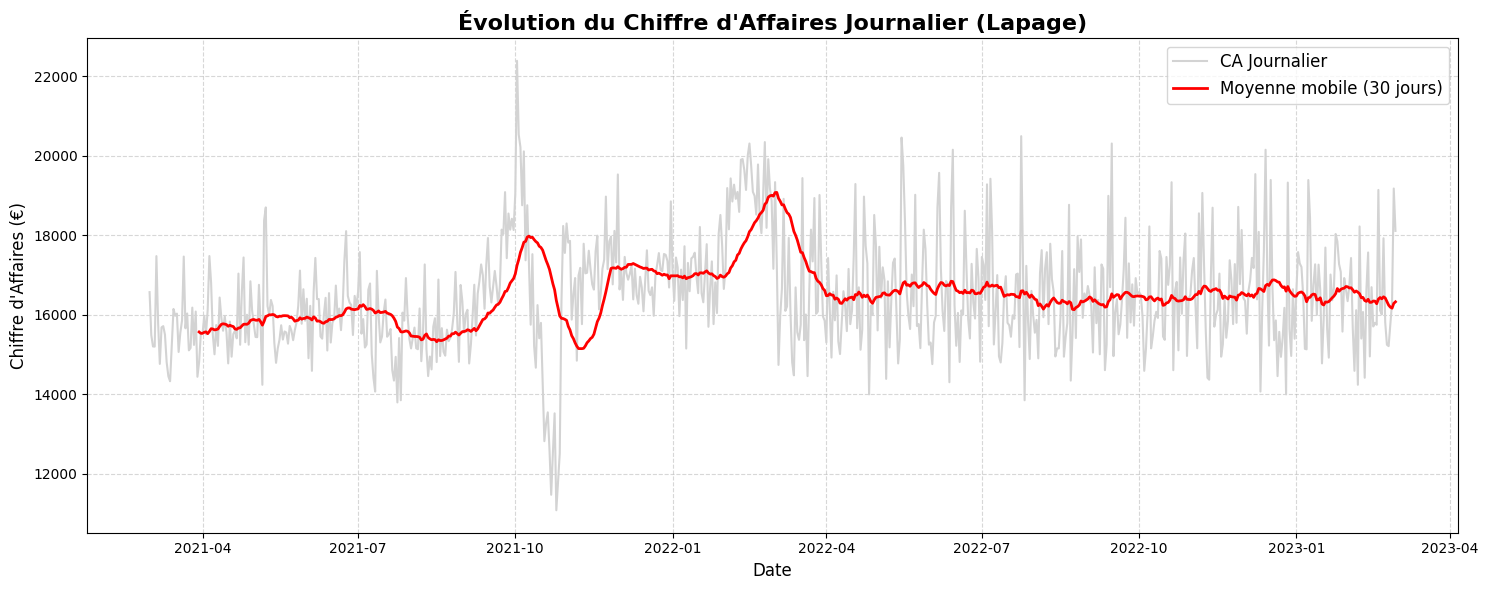

In [8]:
# 1. Préparation des données journalières
# On extrait uniquement la date (sans l'heure) pour le regroupement
df_final['jour'] = df_final['date'].dt.date

# On calcule le CA pour chaque jour
ca_journalier = df_final.groupby('jour')['price'].sum().reset_index()

# 2. Calcul de la Moyenne Mobile (sur 30 jours)
ca_journalier['moyenne_mobile_30j'] = ca_journalier['price'].rolling(window=30).mean()

# 3. Création du graphique avec Matplotlib
plt.figure(figsize=(15, 6))

# La courbe du CA journalier (en gris clair pour ne pas surcharger)
plt.plot(ca_journalier['jour'], ca_journalier['price'], label='CA Journalier', color='lightgray')

# La courbe de la moyenne mobile (en rouge et plus épaisse pour ressortir)
plt.plot(ca_journalier['jour'], ca_journalier['moyenne_mobile_30j'], label='Moyenne mobile (30 jours)', color='red', linewidth=2)

# Personnalisation
plt.title('Évolution du Chiffre d\'Affaires Journalier (Lapage)', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Chiffre d\'Affaires (€)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

# Affichage
plt.tight_layout()
plt.show()

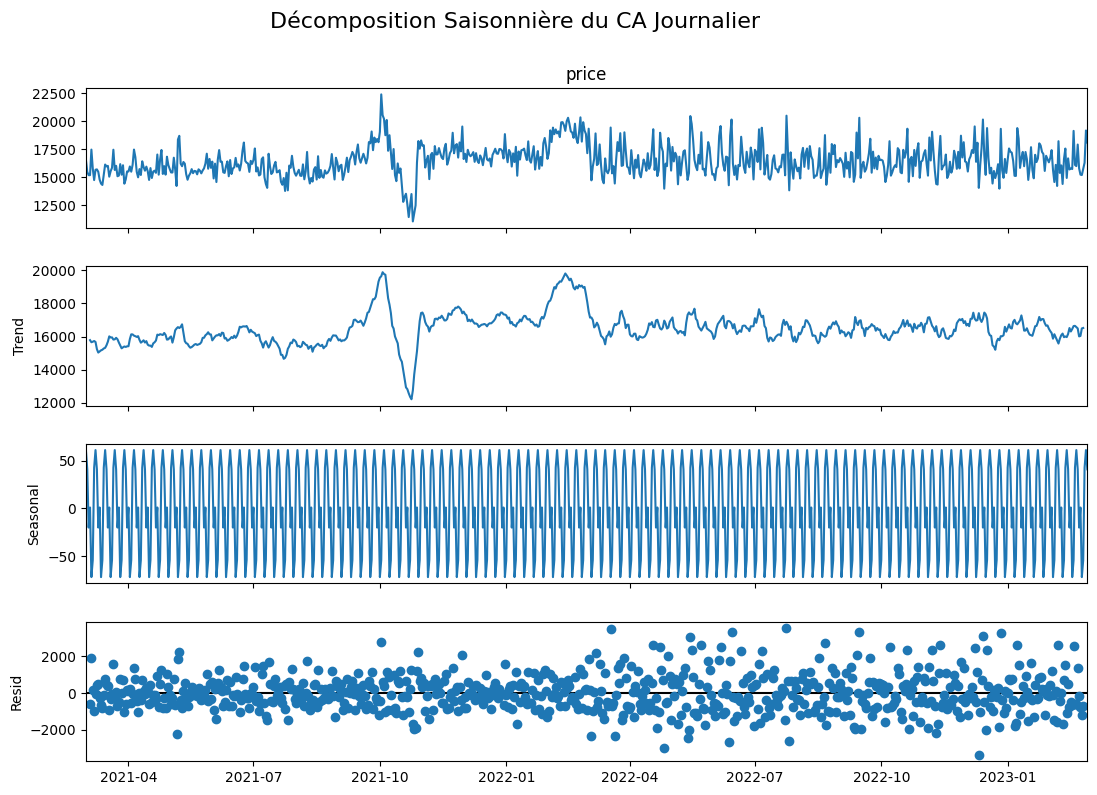

In [9]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

# On agrège le Chiffre d'Affaires par jour sur la table globale (df_final)
ca_journalier = df_final.groupby('jour')['price'].sum()

# Décomposition (période 7 pour isoler la tendance hebdomadaire)
decomposition = seasonal_decompose(ca_journalier, model='additive', period=7)

# Affichage de la décomposition
fig = decomposition.plot()
fig.set_size_inches(12, 8)
plt.suptitle('Décomposition Saisonnière du CA Journalier', fontsize=16, y=1.02)
plt.show()

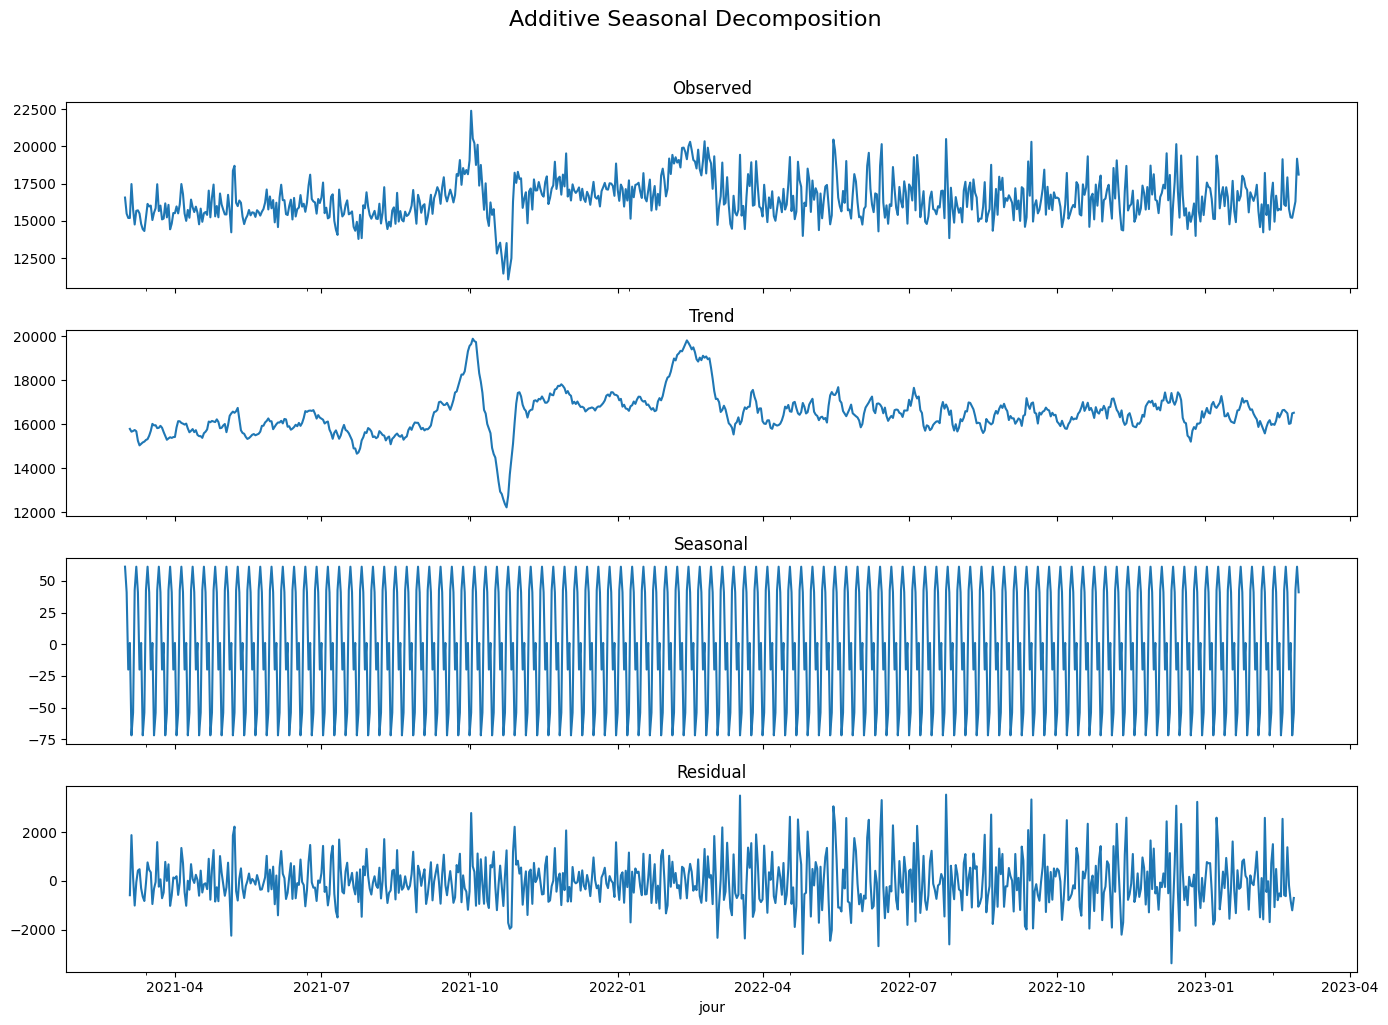

In [10]:
fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)

decomposition.observed.plot(ax=axes[0], title='Observed')
decomposition.trend.plot(ax=axes[1], title='Trend')
decomposition.seasonal.plot(ax=axes[2], title='Seasonal')
decomposition.resid.plot(ax=axes[3], title='Residual')

plt.suptitle('Additive Seasonal Decomposition', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

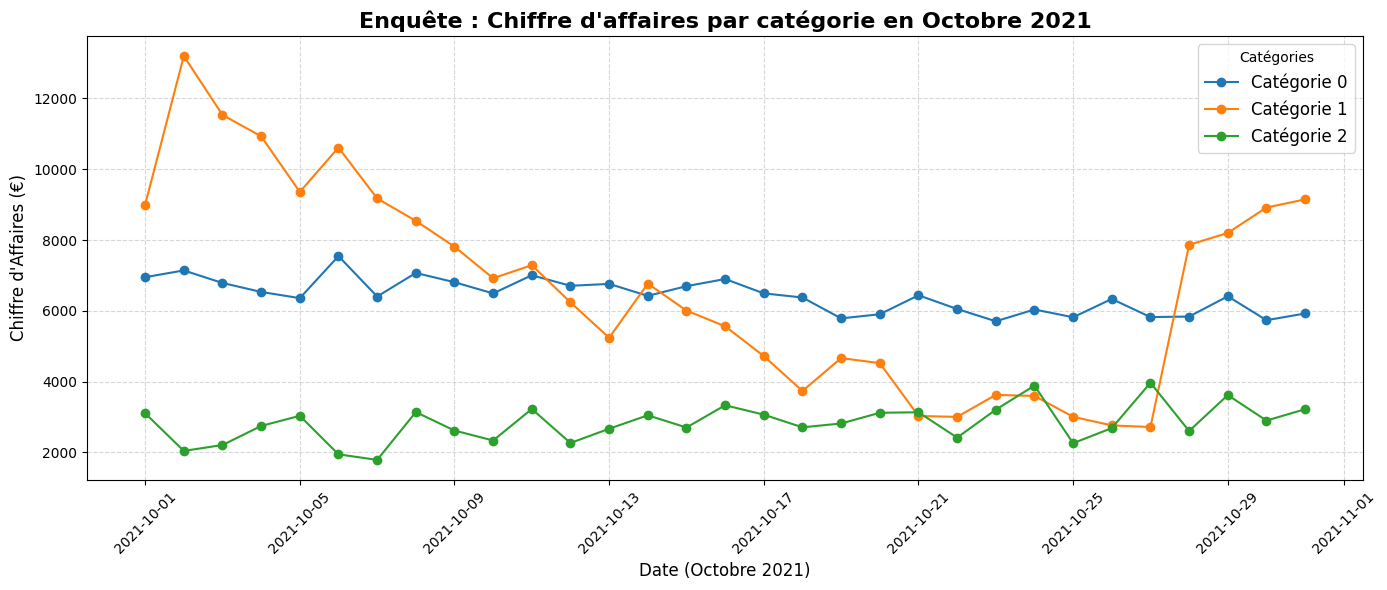

In [11]:
# 1. On filtre les données uniquement sur le mois d'octobre 2021
df_octobre = df_final[(df_final['date'] >= '2021-10-01') & (df_final['date'] < '2021-11-01')]

# 2. On groupe le chiffre d'affaires par jour ET par catégorie
ca_octobre_categ = df_octobre.groupby([df_octobre['date'].dt.date, 'categ'])['price'].sum().reset_index()

# 3. Création du graphique pour l'enquête
plt.figure(figsize=(14, 6))

# On trace une courbe pour chaque catégorie présente
for categorie in ca_octobre_categ['categ'].unique():
    donnees_cat = ca_octobre_categ[ca_octobre_categ['categ'] == categorie]
    plt.plot(donnees_cat['date'], donnees_cat['price'], marker='o', label=f'Catégorie {categorie}')

# Personnalisation du graphique
plt.title('Enquête : Chiffre d\'affaires par catégorie en Octobre 2021', fontsize=16, fontweight='bold')
plt.xlabel('Date (Octobre 2021)', fontsize=12)
plt.ylabel('Chiffre d\'Affaires (€)', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title="Catégories", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [12]:
# On compte le nombre de fois où chaque produit a été vendu
ventes_par_produit = df_final.groupby('id_prod').size().reset_index(name='nombre_ventes')

# On trie du plus vendu au moins vendu
ventes_triees = ventes_par_produit.sort_values(by='nombre_ventes', ascending=False)

print("TOP 5 des produits les plus vendus :")
display(ventes_triees.head(5))

print("\nFLOP 5 des produits les moins vendus :")
display(ventes_triees.tail(5))

TOP 5 des produits les plus vendus :


,id_prod,nombre_ventes
2591,1_369,2340
2644,1_417,2269
2641,1_414,2246
2733,1_498,2202
2653,1_425,2163



FLOP 5 des produits les moins vendus :


,id_prod,nombre_ventes
166,0_1151,1
313,0_1284,1
1784,0_541,1
3175,2_23,1
3247,2_81,1


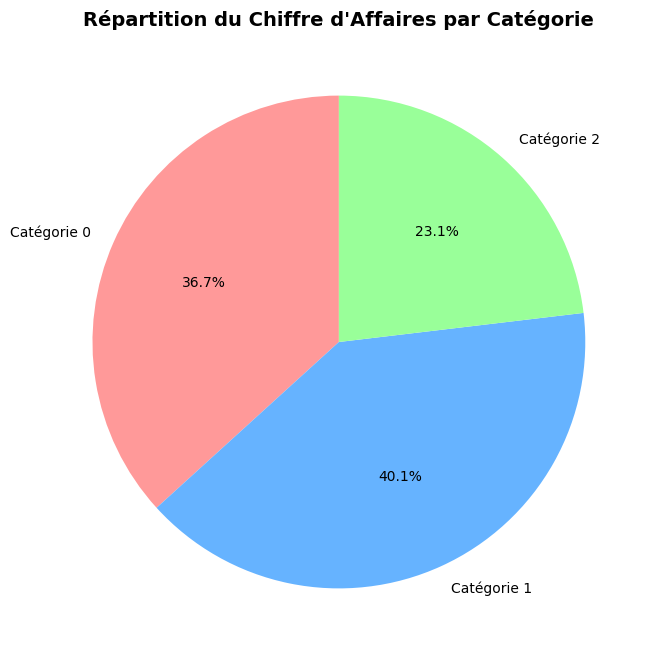

In [13]:
# Calcul du CA par catégorie
ca_par_categorie = df_final.groupby('categ')['price'].sum()

# Création du graphique en secteurs
plt.figure(figsize=(8, 8))
plt.pie(ca_par_categorie, labels=[f'Catégorie {cat}' for cat in ca_par_categorie.index], 
        autopct='%1.1f%%', startangle=90, colors=['#ff9999','#66b3ff','#99ff99'])

plt.title('Répartition du Chiffre d\'Affaires par Catégorie', fontsize=14, fontweight='bold')
plt.show()

##  Partie 3 : Concentration du Chiffre d'Affaires (B2B vs B2C)
Tous les clients ont-ils le même poids dans notre chiffre d'affaires ? Pour le savoir, nous allons tracer une **Courbe de Lorenz** et calculer le **Coefficient de Gini**. Cela nous permettra de voir si une minorité d'acheteurs génère la majorité de nos revenus.

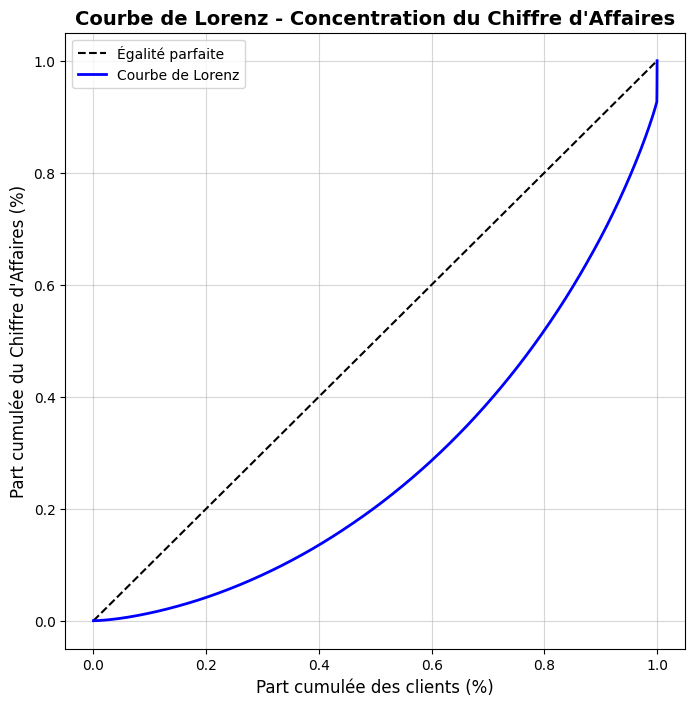

In [14]:
# 1. Calcul du CA par client
ca_par_client = df_final.groupby('client_id')['price'].sum().sort_values().values

# 2. Calcul des pourcentages cumulés pour Lorenz
lorenz_ca = np.cumsum(ca_par_client) / ca_par_client.sum()
lorenz_ca = np.insert(lorenz_ca, 0, 0) # On commence à 0

# 3. Création du graphique
plt.figure(figsize=(8, 8))

# La courbe d'égalité parfaite (si chaque client dépensait exactement pareil)
plt.plot(np.linspace(0, 1, len(lorenz_ca)), np.linspace(0, 1, len(lorenz_ca)), 
         color='black', linestyle='--', label='Égalité parfaite')

# La courbe de Lorenz de nos clients
plt.plot(np.linspace(0, 1, len(lorenz_ca)), lorenz_ca, color='blue', linewidth=2, label='Courbe de Lorenz')

plt.title('Courbe de Lorenz - Concentration du Chiffre d\'Affaires', fontsize=14, fontweight='bold')
plt.xlabel('Part cumulée des clients (%)', fontsize=12)
plt.ylabel('Part cumulée du Chiffre d\'Affaires (%)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.5)
plt.show()

In [15]:
import numpy as np

# On utilise la nouvelle fonction trapezoid pour éviter l'avertissement
surface_sous_courbe = np.trapezoid(lorenz_ca, dx=1/len(ca_par_client))

# La formule mathématique du coefficient de Gini
indice_gini = 1 - 2 * surface_sous_courbe

print(f" Le coefficient de Gini est de : {indice_gini:.2f}")

# En e-commerce, un Gini au-dessus de 0.4 montre déjà une forte concentration
if indice_gini > 0.4:
    print(" Interprétation : L'inégalité est significative. Une minorité de clients génère une grosse partie du CA (confirmant les clients B2B).")
else:
    print(" Interprétation : La répartition du chiffre d'affaires est plutôt égalitaire.")

 Le coefficient de Gini est de : 0.44
 Interprétation : L'inégalité est significative. Une minorité de clients génère une grosse partie du CA (confirmant les clients B2B).


> ** Conclusion Stratégique :** Le coefficient de Gini s'élève à 0.44. Dans l'e-commerce, c'est un indicateur d'inégalité fort. La courbe de Lorenz nous montre que 4 clients génèrent à eux seuls plus de 7% de notre chiffre d'affaires (près de 900 000 €). Ce sont nos clients professionnels (B2B). 
> **Action :** Pour ne pas fausser l'analyse des comportements des particuliers (B2C), nous allons exclure ces 4 clients B2B pour la suite de l'étude.

In [16]:
# 1. On calcule le CA par client, trié du plus grand au plus petit
top_clients = df_final.groupby('client_id')['price'].sum().reset_index()
top_clients = top_clients.sort_values(by='price', ascending=False)

# On affiche le Top 10
print(" Le TOP 10 des plus gros clients :")
display(top_clients.head(10))

# 2. Calcul du poids des 4 plus gros clients
ca_top_4 = top_clients.head(4)['price'].sum()
ca_total = df_final['price'].sum()
pourcentage_top_4 = (ca_top_4 / ca_total) * 100

print("-" * 50)
print(f" Les 4 plus gros clients ont dépensé à eux seuls : {ca_top_4:,.2f} €")
print(f" Cela représente {pourcentage_top_4:.2f} % du Chiffre d'Affaires total de Lapage ")

 Le TOP 10 des plus gros clients :


,client_id,price
677,c_1609,326039.89
4388,c_4958,290227.03
6337,c_6714,153918.60
2724,c_3454,114110.57
634,c_1570,5285.82
2513,c_3263,5276.87
1268,c_2140,5260.18
2108,c_2899,5214.05
7006,c_7319,5155.77
7715,c_7959,5135.75


--------------------------------------------------
 Les 4 plus gros clients ont dépensé à eux seuls : 884,296.09 €
 Cela représente 7.35 % du Chiffre d'Affaires total de Lapage 


In [17]:
# 1. On liste nos 4 clients B2B
clients_b2b = ['c_1609', 'c_4958', 'c_6714', 'c_3454']

# 2. On crée un nouveau DataFrame en excluant ces clients 
df_b2c = df_final[~df_final['client_id'].isin(clients_b2b)].copy()

# 3. Calcul de l'âge (l'analyse se passe en 2022)
df_b2c['age'] = 2022 - df_b2c['birth']

print(f"Taille de la base avec les B2B : {len(df_final)} lignes")
print(f"Taille de la base sans les B2B (B2C uniquement) : {len(df_b2c)} lignes")

Taille de la base avec les B2B : 687534 lignes
Taille de la base sans les B2B (B2C uniquement) : 640734 lignes


##  Partie 4 : Analyses Bivariées et Tests Statistiques (Demandes de Julie)
Nous travaillons désormais uniquement sur les clients particuliers (B2C).
**Hypothèse 1 : Y a-t-il un lien entre le sexe d'un client et la catégorie de livre achetée ?**
* **Variables :** Qualitative (Sexe) / Qualitative (Catégorie)
* **Test choisi :** Chi-2 d'indépendance avec calcul du V de Cramer (pour mesurer la force de la liaison).

In [18]:
import scipy.stats as st

# 1. Création du tableau de contingence (Tableau croisé)
contingency_table = pd.crosstab(df_b2c['sex'], df_b2c['categ'])

print(" Tableau de contingence (Nombre d'achats) :")
display(contingency_table)

display(pd.crosstab(df_b2c['sex'], df_b2c['categ'],margins=True, normalize='index'))
display(pd.crosstab(df_b2c['sex'], df_b2c['categ'],margins=True, normalize='columns'))
        
# 2. Test du Chi-deux
chi2, p_value, dof, expected = st.chi2_contingency(contingency_table)

print("-" * 50)
print(f"Résultat du test du Chi-2 : {chi2:.2f}")
print(f"P-value : {p_value}")

# 3. Interprétation automatique
if p_value < 0.05:
    print(" Conclusion : La p-value est très petite. Il y a une CORRÉLATION SIGNIFICATIVE entre le genre et la catégorie achetée.")
else:
    print(" Conclusion : La p-value est grande. Il n'y a PAS de corrélation significative.")


 Tableau de contingence (Nombre d'achats) :


categ,0,1,2
sex,,,
f,200793,115721,16980
m,186488,104884,15868


categ,0,1,2
sex,,,
f,0.602089,0.346996,0.050915
m,0.606978,0.341375,0.051647
All,0.604433,0.344300,0.051266


categ,0,1,2,All
sex,,,,
f,0.518469,0.524562,0.516926,0.520487
m,0.481531,0.475438,0.483074,0.479513


--------------------------------------------------
Résultat du test du Chi-2 : 22.67
P-value : 1.1955928116587024e-05
 Conclusion : La p-value est très petite. Il y a une CORRÉLATION SIGNIFICATIVE entre le genre et la catégorie achetée.


> ** Interprétation :** La p-value est très inférieure à 0.05, le test est significatif. Le sexe du client influence bien le type de livre acheté, même si la force de cette liaison (V de Cramer) reste modérée.

In [19]:
# Test du Chi-2 avec Pingouin
expected, observed, stats = pg.chi2_independence(data=df_b2c, x='sex', y='categ')

print(" Résultats du Test du Chi-2 et V de Cramer :")
display(stats)

 Résultats du Test du Chi-2 et V de Cramer :


,test,lambda,chi2,dof,pval,cramer,power
0,pearson,1.000000,22.668567,2.0,0.000012,0.005948,0.993044
1,cressie-read,0.666667,22.669359,2.0,0.000012,0.005948,0.993045
2,log-likelihood,0.000000,22.671010,2.0,0.000012,0.005948,0.993049
3,freeman-tukey,-0.500000,22.672305,2.0,0.000012,0.005949,0.993051
4,mod-log-likelihood,-1.000000,22.673649,2.0,0.000012,0.005949,0.993054
5,neyman,-2.000000,22.676484,2.0,0.000012,0.005949,0.993059


**Hypothèse 2 : L'âge du client influence-t-il le montant total, la fréquence d'achat et la taille du panier moyen ?**
* **Variables :** Quantitative (Âge) / Quantitatives (Montant, Fréquence, Panier)
* **Méthodologie :** Avant d'utiliser un test de Pearson, nous devons vérifier la condition de normalité (Test de Shapiro-Wilk).

In [20]:
import scipy.stats as st

# 1. Création de la table résumé par client
clients_stats = df_b2c.groupby(['client_id', 'age']).agg(
    montant_total=('price', 'sum'),
    frequence_achat=('session_id', 'nunique') # nunique compte le nombre de vrais paniers différents
).reset_index()

# 2. Calcul du panier moyen
clients_stats['panier_moyen'] = clients_stats['montant_total'] / clients_stats['frequence_achat']

print("Aperçu de notre nouvelle table clients :")
display(clients_stats.head())

print("-" * 50)
# 3. Test de normalité (Shapiro-Wilk) sur le montant total
# L'hypothèse nulle (H0) de Shapiro est : "La distribution suit une loi normale"
stat_shapiro, p_val_shapiro = st.shapiro(clients_stats['montant_total'])

print("Test préalable : Test de normalité de Shapiro-Wilk sur le Montant Total")
print(f"P-value de Shapiro : {p_val_shapiro}")

if p_val_shapiro < 0.05:
    print("Conclusion Shapiro : P-value < 0.05. Rejet de H0. La distribution n'est PAS normale.")
    print(" Action : Nous n'avons pas le droit d'utiliser Pearson. Nous utilisons le test de Spearman.")
    
    # 4. Test de corrélation de Spearman (Alternative non-paramétrique)
    coef_corr, p_value = st.spearmanr(clients_stats['age'], clients_stats['montant_total'])
    nom_test = "Spearman"

else:
    print("Conclusion Shapiro : P-value > 0.05. La distribution est normale.")
    print(" Action : Nous pouvons utiliser le test de Pearson.")
    
    # Test de corrélation de Pearson
    coef_corr, p_value = st.pearsonr(clients_stats['age'], clients_stats['montant_total'])
    nom_test = "Pearson"

print("-" * 50)
# 5. Résultat final de la corrélation
print(f" Test 1 : Âge vs Montant Total (Test utilisé : {nom_test})")
print(f"Coefficient de corrélation de {nom_test} : {coef_corr:.3f}")
print(f"P-value : {p_value}")

if p_value < 0.05:
    print("Conclusion finale : La corrélation est SIGNIFICATIVE.")
else:
    print("Conclusion finale : PAS de corrélation.")

Aperçu de notre nouvelle table clients :


,client_id,age,montant_total,frequence_achat,panier_moyen
0,c_1,67,629.02,34,18.500588
1,c_10,66,1353.60,34,39.811765
2,c_100,30,254.85,5,50.970000
3,c_1000,56,2291.88,94,24.381702
4,c_1001,40,1823.85,47,38.805319


--------------------------------------------------
Test préalable : Test de normalité de Shapiro-Wilk sur le Montant Total
P-value de Shapiro : 1.482448662635367e-58
Conclusion Shapiro : P-value < 0.05. Rejet de H0. La distribution n'est PAS normale.
 Action : Nous n'avons pas le droit d'utiliser Pearson. Nous utilisons le test de Spearman.
--------------------------------------------------
 Test 1 : Âge vs Montant Total (Test utilisé : Spearman)
Coefficient de corrélation de Spearman : -0.185
P-value : 1.0212910436382683e-66
Conclusion finale : La corrélation est SIGNIFICATIVE.


C:\Users\remyd\AppData\Local\Programs\Python\Python313\Lib\site-packages\scipy\stats\_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 8596.
  res = hypotest_fun_out(*samples, **kwds)


> Nous n'avons pas le droit d'utiliser Pearson. Nous utilisons le test de Spearman.
> ⚠️ Note : Le test de Shapiro-Wilk renvoie un avertissement car notre échantillon dépasse 5000 individus (N=8596). Cependant, la p-value étant extrêmement proche de 0 (asymétrie forte des dépenses e-commerce), la conclusion de non-normalité reste parfaitement valide.

In [21]:
# Tests de Spearman avec Pingouin
corr_montant = pg.corr(x=clients_stats['age'], y=clients_stats['montant_total'], method='spearman')
corr_freq = pg.corr(x=clients_stats['age'], y=clients_stats['frequence_achat'], method='spearman')
corr_panier = pg.corr(x=clients_stats['age'], y=clients_stats['panier_moyen'], method='spearman')

print("1. Corrélation Âge vs Montant total :")
display(corr_montant) 

print("2. Corrélation Âge vs Fréquence d'achat :")
display(corr_freq)

print("3. Corrélation Âge vs Panier Moyen :")
display(corr_panier)

1. Corrélation Âge vs Montant total :


,n,r,CI95,p_val,power
spearman,8596,-0.184538,"[-0.2, -0.16]",1.021291e-66,1.0


2. Corrélation Âge vs Fréquence d'achat :


,n,r,CI95,p_val,power
spearman,8596,0.211964,"[0.19, 0.23]",6.629168e-88,1.0


3. Corrélation Âge vs Panier Moyen :


,n,r,CI95,p_val,power
spearman,8596,-0.700551,"[-0.71, -0.69]",0.0,1.0


> ** Interprétation Métier des Corrélations :**
> 1. **Âge vs Montant Total (r = -0.18) :** Corrélation faible. Les plus âgés dépensent légèrement moins au global.
> 2. **Âge vs Fréquence (r = 0.21) :** Corrélation positive. Plus le client vieillit, plus il est fidèle et achète souvent.
> 3. **Âge vs Panier Moyen (r = -0.70) :** Corrélation très forte et négative ! La taille du panier s'effondre avec l'âge. Nos jeunes clients viennent rarement, mais dépensent des fortunes d'un seul coup.

 Test 2 : Âge vs Fréquence d'achat (Spearman)
Coefficient : 0.212 | P-value : 6.629168433162815e-88
 Conclusion : Corrélation SIGNIFICATIVE.



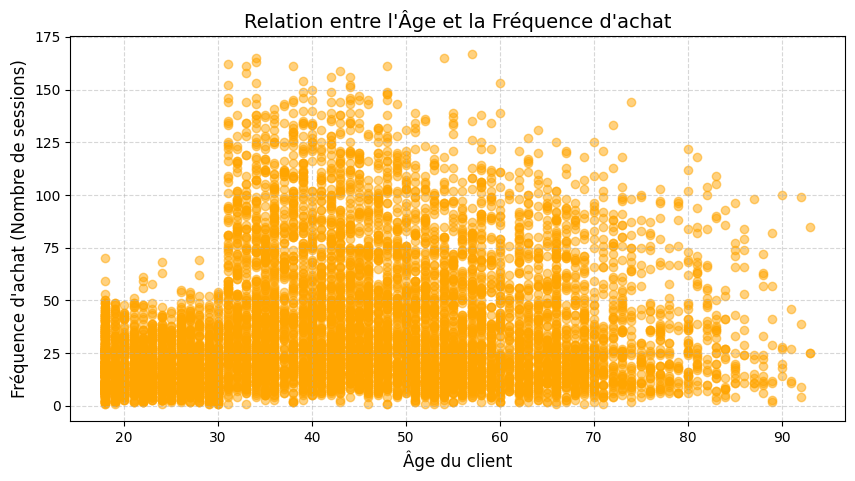

 Test 3 : Âge vs Panier Moyen (Spearman)
Coefficient : -0.701 | P-value : 0.0
 Conclusion : Corrélation SIGNIFICATIVE.


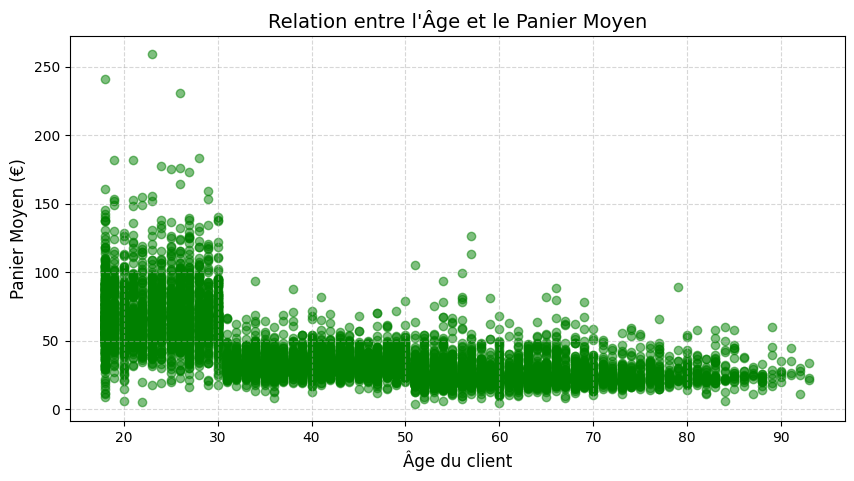

In [22]:
# Test 2 : Corrélation Âge vs Fréquence d'achat (Test de Spearman)
coef_freq, p_value_freq = st.spearmanr(clients_stats['age'], clients_stats['frequence_achat'])

print(" Test 2 : Âge vs Fréquence d'achat (Spearman)")
print(f"Coefficient : {coef_freq:.3f} | P-value : {p_value_freq}")
if p_value_freq < 0.05:
    print(" Conclusion : Corrélation SIGNIFICATIVE.\n")
else:
    print(" Conclusion : PAS de corrélation.\n")
    
# Graphique Fréquence
plt.figure(figsize=(10, 5))
plt.scatter(clients_stats['age'], clients_stats['frequence_achat'], alpha=0.5, color='orange') 
plt.title("Relation entre l'Âge et la Fréquence d'achat", fontsize=14)
plt.xlabel("Âge du client", fontsize=12)
plt.ylabel("Fréquence d'achat (Nombre de sessions)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# ---------------------------------------------------------

# Test 3 : Corrélation Âge vs Panier Moyen (Test de Spearman)
coef_panier, p_value_panier = st.spearmanr(clients_stats['age'], clients_stats['panier_moyen'])

print(" Test 3 : Âge vs Panier Moyen (Spearman)")
print(f"Coefficient : {coef_panier:.3f} | P-value : {p_value_panier}")
if p_value_panier < 0.05:
    print(" Conclusion : Corrélation SIGNIFICATIVE.")
else:
    print(" Conclusion : PAS de corrélation.")
    
# Graphique Panier Moyen
plt.figure(figsize=(10, 5))
plt.scatter(clients_stats['age'], clients_stats['panier_moyen'], alpha=0.5, color='green')
plt.title("Relation entre l'Âge et le Panier Moyen", fontsize=14)
plt.xlabel("Âge du client", fontsize=12)
plt.ylabel("Panier Moyen (€)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)


**Hypothèse 3 : L'âge explique-t-il le choix de la catégorie (et donc ce fameux panier moyen élevé chez les jeunes) ?**
* **Variables :** Qualitative (Catégorie) / Quantitative (Âge)
* **Méthodologie :** Avant de réaliser une ANOVA, nous testons l'égalité des variances (Homoscédasticité via le test de Levene).

In [23]:
# 1. Test d'Homoscédasticité (Condition pour l'ANOVA)
print("1. Test d'Homoscédasticité :")
homo_test = pg.homoscedasticity(data=df_b2c, dv='age', group='categ')
display(homo_test)

# 2. Test de Kruskal-Wallis (Alternative non-paramétrique à l'ANOVA)
print("\n2. Test de Kruskal-Wallis (Âge vs Catégorie) :")
kruskal_test = pg.kruskal(data=df_b2c, dv='age', between='categ')
display(kruskal_test)

# L'Eta-carré pour Kruskal-Wallis se calcule via la formule H / (n - 1)
H = kruskal_test['H'].iloc[0]
n = len(df_b2c) 

eta_carre = H / (n - 1)

print(f"\n La force de la liaison (Eta-carré) est de : {eta_carre:.3f}")

1. Test d'Homoscédasticité :


,W,pval,equal_var
levene,24651.780367,0.0,False



2. Test de Kruskal-Wallis (Âge vs Catégorie) :


,Source,ddof1,H,p_unc
Kruskal,categ,2,71359.734121,0.0



 La force de la liaison (Eta-carré) est de : 0.111


> ** Interprétation Finale :** Le test d'homoscédasticité a échoué (les variances sont très différentes selon les catégories). Nous avons donc utilisé le **test de Kruskal-Wallis**.
> La p-value de 0.0 confirme un lien extrêmement puissant entre l'âge et la catégorie. Le Boxplot le prouve visuellement : **Les jeunes achètent le monopole de la Catégorie 2**. Étant donné que cette catégorie regroupe les livres les plus chers du magasin, cela explique parfaitement pourquoi leur panier moyen crève le plafond !

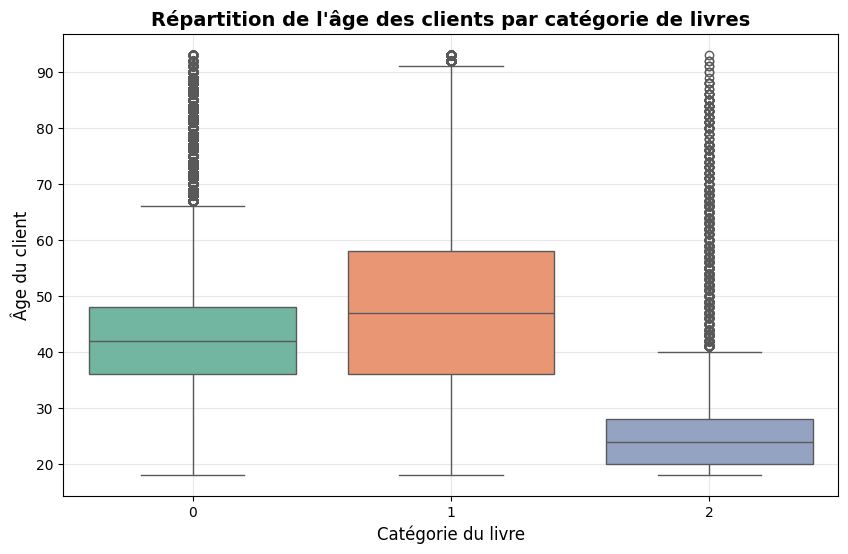

In [24]:
# Préparation visuelle : Le Boxplot (Boîte à moustaches)
plt.figure(figsize=(10, 6))
sns.boxplot(x='categ', y='age', data=df_b2c, hue='categ', palette='Set2', legend=False)
plt.title('Répartition de l\'âge des clients par catégorie de livres', fontsize=14, fontweight='bold')
plt.xlabel('Catégorie du livre', fontsize=12)
plt.ylabel('Âge du client', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

# Note : La conclusion statistique a déjà été validée par la p-value de Kruskal-Wallis.